In [18]:
import pandas as pd
import linearmodels.panel as lmp
import statsmodels.api as sm
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy.linalg as la
from scipy import stats
from linearmodels.panel import RandomEffects

In [19]:
df = pd.read_csv('C:/Users/edins/OneDrive/Escritorio/machine learning/data/panel_eps.csv')
#eliminar columnas a no usar:
df.drop(columns=['publicemp', 'size','children','lmp','fondoa','fondob','fondoc','fondod','fondoe','informal','selfemp','occupation'], inplace=True) 

#asignamos sueldo 0 a aquellos que esten inactivos o desempleados, lo mismo para horas trabajadas
df.loc[(df['situation'] == 4) & (df['wage'].isna()), 'wage'] = 0
df.loc[(df['situation'] == 2) & (df['wage'].isna()), 'wage'] = 0

df.loc[(df['situation'] == 4) & (df['hours'].isna()), 'hours'] = 0
df.loc[(df['situation'] == 2) & (df['hours'].isna()), 'hours'] = 0

#asumimos que aquellos NaN en las categorias de illness, cronica, nocronica, y mental son porque no las padecen
df['illness'] = df['illness'].fillna(0)
df['cronica'] = df['cronica'].fillna(0)
df['nocronica'] = df['nocronica'].fillna(0)
df['mental'] = df['mental'].fillna(0)

df

,folio_n20,year,time,edad,hombre,edu,region,status,kids,situation,...,hours,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
0,124560204870,4,2,49,0.0,7.0,5.0,3.0,1,4,...,0.0,NaN,0.0,0.00,0,58.0,1.0,0.0,1.0,0.0
1,124560204870,6,3,51,0.0,4.0,5.0,3.0,1,4,...,0.0,0.0,0.0,0.00,0,55.0,0.0,0.0,0.0,0.0
2,124560204870,9,4,54,0.0,5.0,5.0,3.0,1,4,...,0.0,1.0,0.0,0.00,0,70.0,1.0,0.0,0.0,1.0
3,124560204870,12,5,57,0.0,4.0,NaN,5.0,0,3,...,20.0,0.0,0.0,NaN,0,70.0,1.0,0.0,0.0,0.0
4,124560205935,2,1,1982,0.0,15.0,13.0,3.0,1,4,...,0.0,1.0,0.0,989038.06,19,75.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96841,128133653188,12,5,1992,0.0,16.0,NaN,3.0,0,4,...,0.0,1.0,0.0,NaN,7,80.0,0.0,0.0,0.0,0.0
96842,128133692735,12,5,1992,0.0,12.0,NaN,2.0,0,3,...,50.0,1.0,1.0,NaN,7,80.0,1.0,0.0,0.0,0.0
96843,128133702320,12,5,1992,0.0,15.0,NaN,5.0,0,4,...,0.0,1.0,1.0,NaN,7,75.0,0.0,0.0,0.0,0.0
96844,128133728022,12,5,1992,0.0,8.0,NaN,2.0,0,3,...,48.0,1.0,1.0,NaN,6,70.0,1.0,0.0,0.0,0.0


In [20]:
df.describe()

,folio_n20,year,time,edad,hombre,edu,region,status,kids,situation,...,hours,sistema,cotizando,assets,exp_sist,expectancy,illness,cronica,nocronica,mental
count,9.684600e+04,96846.000000,96846.000000,96846.000000,96796.000000,92920.000000,80848.000000,96736.00000,96846.000000,96846.000000,...,95381.000000,76203.000000,92038.000000,8.075900e+04,96846.000000,70281.000000,96846.000000,96846.000000,96846.000000,96846.000000
mean,1.253178e+11,7.991213,3.493898,1673.399903,0.494979,7.905585,9.148959,2.62378,0.357082,3.248797,...,25.723666,0.867669,0.410504,3.735826e+06,13.473432,131.131273,0.299806,0.177250,0.060777,0.061778
std,1.296642e+09,4.566324,1.727313,711.910128,0.499977,5.106440,3.678007,1.73293,0.479142,0.608103,...,24.425947,0.338852,0.491928,9.292264e+06,10.354177,216.851544,0.458175,0.381883,0.238922,0.240754
min,1.245602e+11,2.000000,1.000000,20.000000,0.000000,0.000000,1.000000,1.00000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000
25%,1.246212e+11,4.000000,2.000000,1982.000000,0.000000,3.000000,6.000000,1.00000,0.000000,3.000000,...,0.000000,1.000000,0.000000,0.000000e+00,3.000000,70.000000,0.000000,0.000000,0.000000,0.000000
50%,1.247076e+11,6.000000,3.000000,1986.000000,0.000000,7.000000,9.000000,2.00000,0.000000,3.000000,...,30.000000,1.000000,0.000000,3.960384e+05,14.000000,80.000000,0.000000,0.000000,0.000000,0.000000
75%,1.248369e+11,12.000000,5.000000,1992.000000,1.000000,12.000000,13.000000,5.00000,1.000000,4.000000,...,45.000000,1.000000,1.000000,3.362842e+06,22.000000,85.000000,1.000000,0.000000,0.000000,0.000000
max,1.281337e+11,15.000000,6.000000,1996.000000,1.000000,19.000000,15.000000,5.00000,1.000000,4.000000,...,140.000000,1.000000,1.000000,2.462820e+08,35.000000,999.000000,1.000000,1.000000,1.000000,1.000000


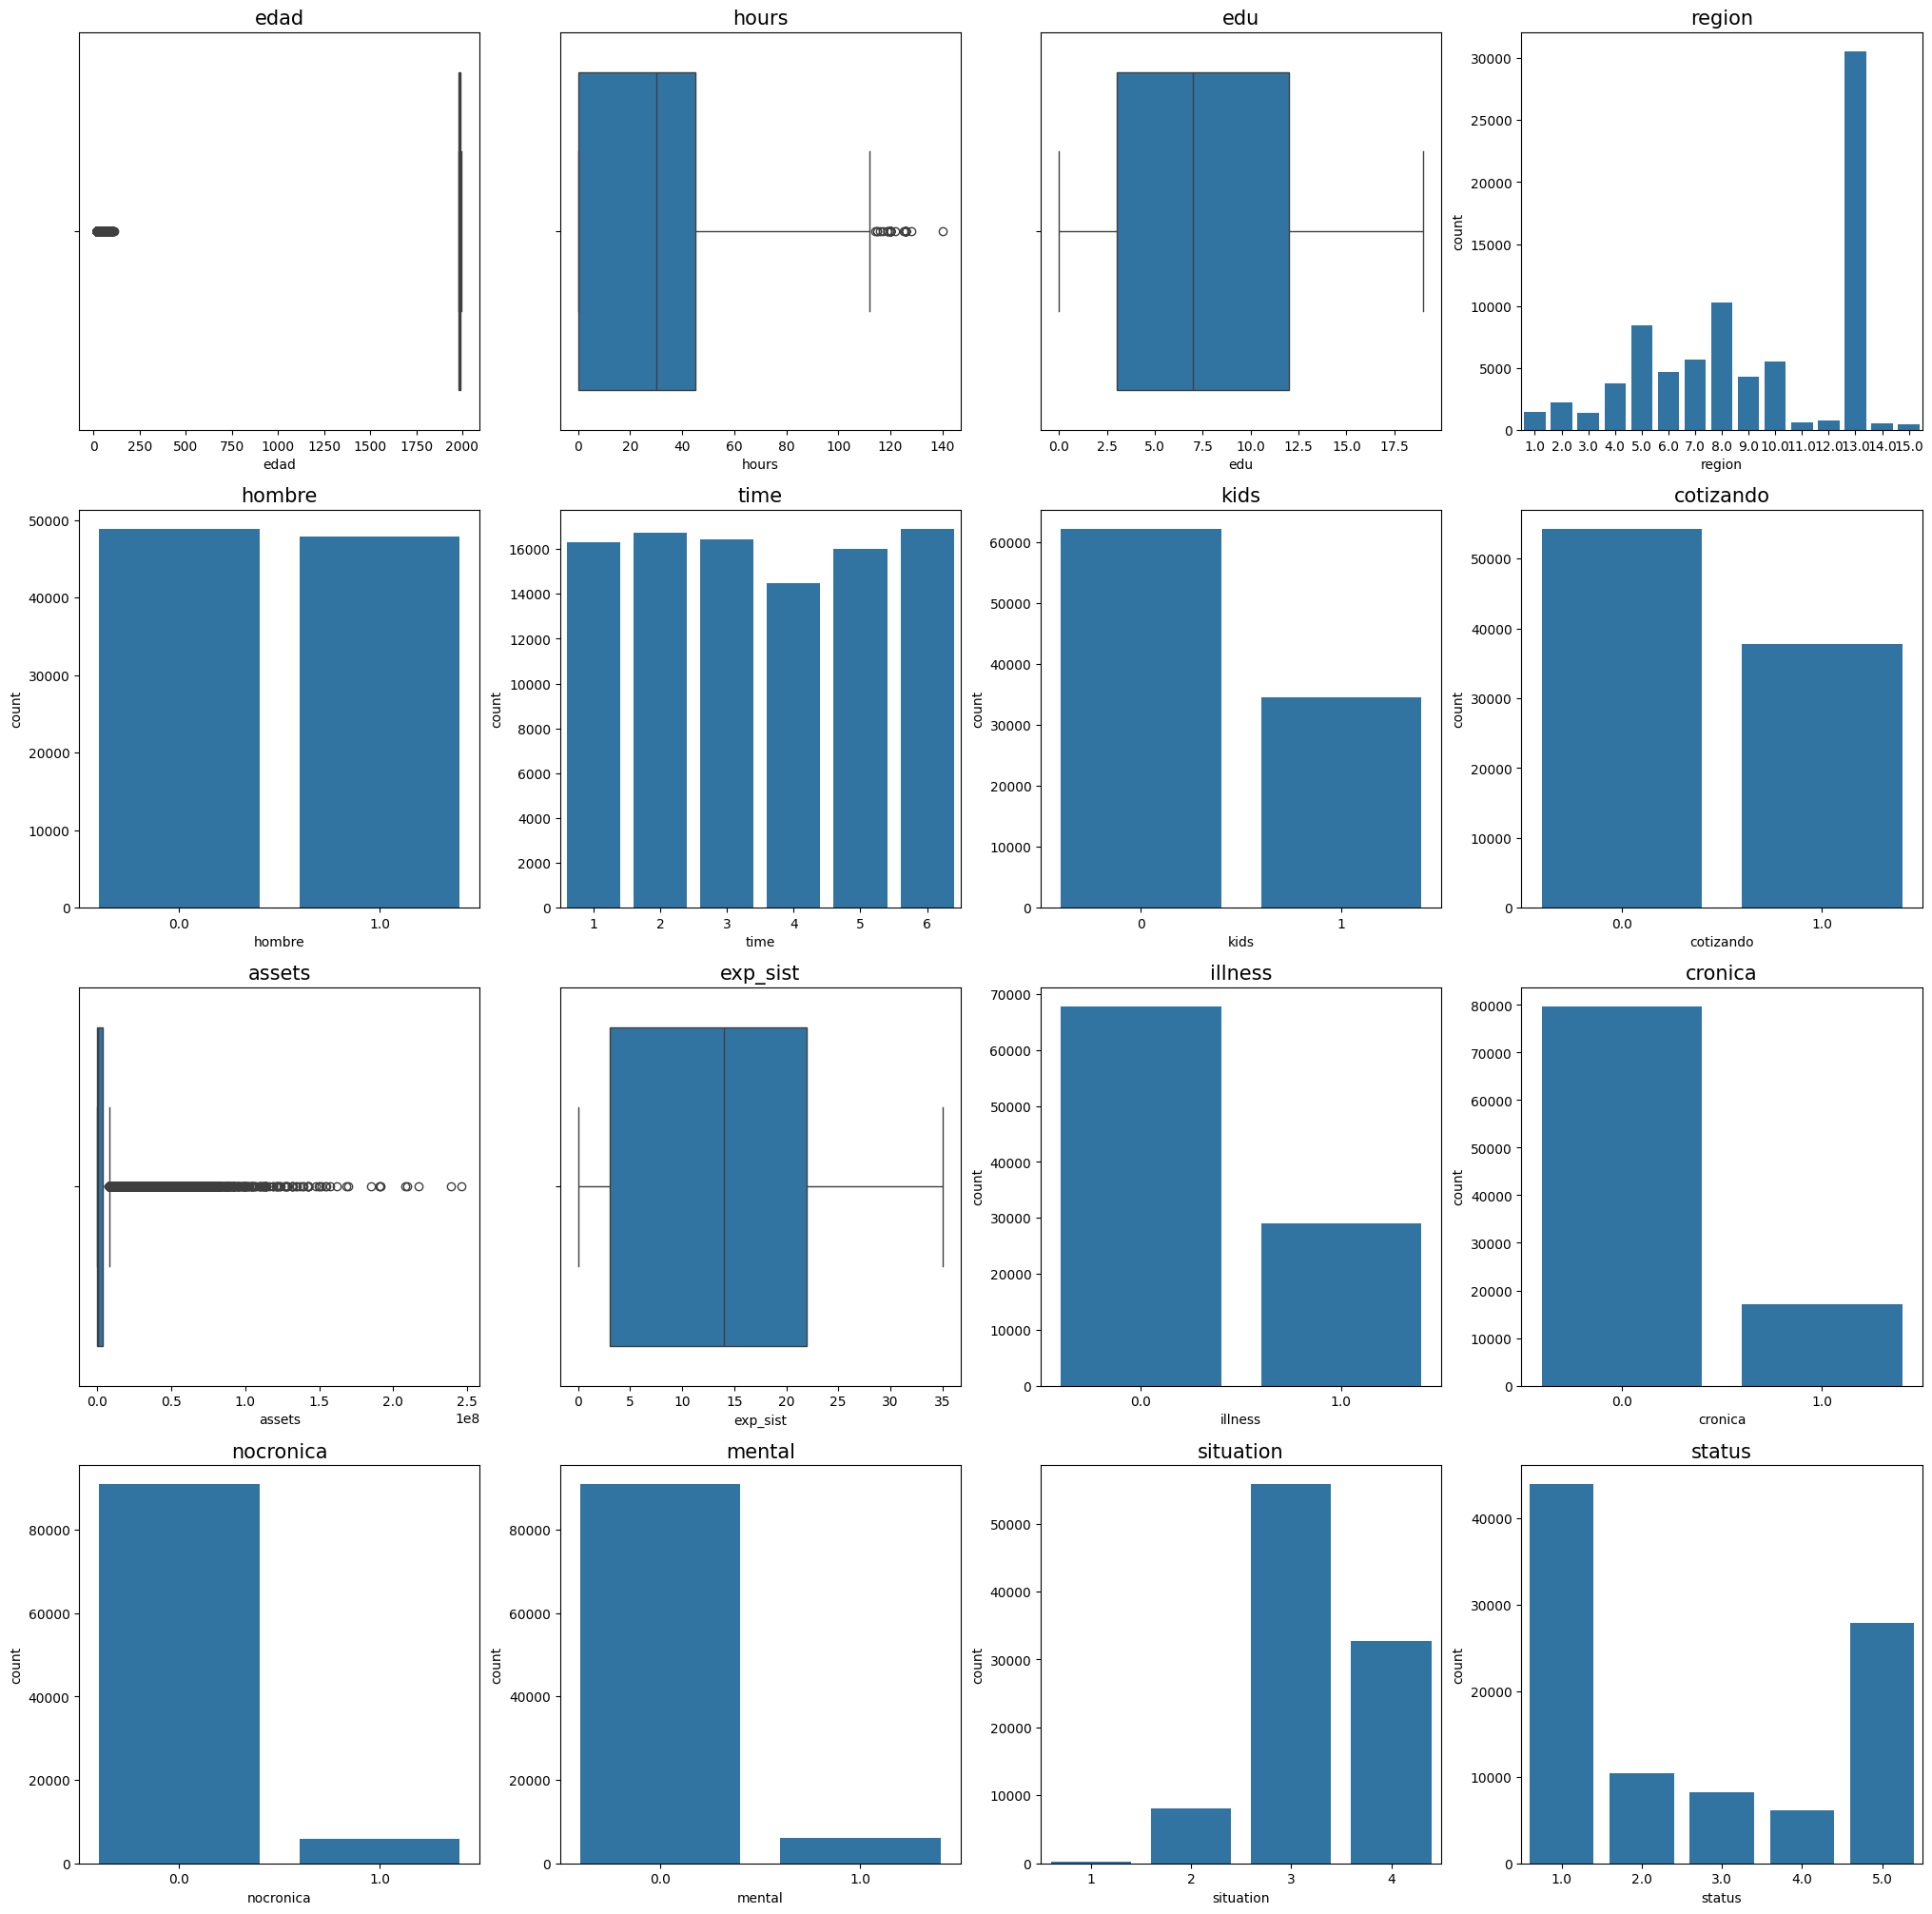

In [21]:
fig, axes = plt.subplots(4, 4,figsize=(25, 25))

sns.boxplot(x=df['edad'],data=df,ax=axes[0, 0])
axes[0, 0].set_title('edad',fontsize=15)

sns.boxplot(x=df['hours'],data=df,ax=axes[0, 1])
axes[0, 1].set_title('hours',fontsize=15)

sns.boxplot(x=df['edu'],data=df,ax=axes[0, 2])
axes[0, 2].set_title('edu',fontsize=15)

sns.countplot(x=df['region'],data=df,ax=axes[0, 3])
axes[0, 3].set_title('region',fontsize=15)
 
# Crear gráfico
sns.countplot(x=df['hombre'],data=df, ax=axes[1,0])
axes[1, 0].set_title('hombre',fontsize=15)

sns.countplot(x=df['time'],data=df,ax=axes[1,1])
axes[1, 1].set_title('time',fontsize=15)

sns.countplot(x=df['kids'],data=df,ax=axes[1,2])
axes[1, 2].set_title('kids',fontsize=15)

sns.countplot(x=df['cotizando'],data=df,ax=axes[1,3])
axes[1, 3].set_title('cotizando',fontsize=15)

sns.boxplot(x=df['assets'],data=df,ax=axes[2, 0])
axes[2, 0].set_title('assets',fontsize=15)

sns.boxplot(x=df['exp_sist'],data=df,ax=axes[2, 1])
axes[2, 1].set_title('exp_sist',fontsize=15)

sns.countplot(x=df['illness'],data=df,ax=axes[2, 2])
axes[2, 2].set_title('illness',fontsize=15)

sns.countplot(x=df['cronica'],data=df,ax=axes[2, 3])
axes[2, 3].set_title('cronica',fontsize=15)

sns.countplot(x=df['nocronica'],data=df,ax=axes[3, 0])
axes[3, 0].set_title('nocronica',fontsize=15)

sns.countplot(x=df['mental'],data=df,ax=axes[3, 1])
axes[3, 1].set_title('mental',fontsize=15)

sns.countplot(x=df['situation'],data=df,ax=axes[3, 2])
axes[3, 2].set_title('situation',fontsize=15)

sns.countplot(x=df['status'],data=df,ax=axes[3, 3])
axes[3, 3].set_title('status',fontsize=15)

plt.show()

Limpieza:

In [22]:

df['edad'] = df['edad'].apply(lambda x: 2025 - x if x > 1900 else x) # transformamos años a edad
df['expectancy'] = df['expectancy'].apply(lambda x: np.nan if x>200 else x) # transformamos a NaN los valores muy altos
df = df.dropna(subset=['expectancy']) #borramos NaN de expectancy
df = df.dropna(subset=['edu']) #borramos NaN de edu (son pocos)
df = df.dropna(subset=['hombre']) #borramos Nan de hombre

#TRANSFORMAR STATUS A DUMMIES

df['status'] = df['status'].map({
    1: 'casado',
    2: 'convive',
    3: 'divorciado',
    4: 'viudo',
    5: 'soltero'})
df = pd.get_dummies(df, columns=['status'], prefix='status', drop_first=True, dtype=int)

#TRANSFORMAR SITUATION A DUMMIES

df['situation'] = df['situation'].map({
    1: 'otro',
    2: 'cesante',
    3: 'trabajando',
    4: 'inactivo'})
df = pd.get_dummies(df, columns=['situation'], prefix='situation', drop_first=True, dtype=int)

#transformamos exp_sist a variable binaria (0 = sin experiencia, 1 = con experiencia)
df['exp_sist'] = (df['exp_sist'] > 0).astype(int) 

df = df.dropna() #quitamos resto de NaN
df


,folio_n20,year,time,edad,hombre,edu,region,kids,exp,wage,...,cronica,nocronica,mental,status_convive,status_divorciado,status_soltero,status_viudo,situation_inactivo,situation_otro,situation_trabajando
4,124560205935,2,1,43,0.0,15.0,13.0,1,6.0,0.0,...,0.0,0.0,0.0,0,1,0,0,1,0,0
5,124560205935,4,2,41,0.0,15.0,13.0,1,6.0,0.0,...,1.0,1.0,0.0,0,1,0,0,1,0,0
6,124560210408,2,1,43,0.0,4.0,13.0,1,22.0,35000.0,...,0.0,0.0,0.0,0,0,0,0,0,0,1
7,124560210408,4,2,41,0.0,4.0,13.0,0,23.0,100000.0,...,0.0,0.0,0.0,0,0,0,0,0,0,1
8,124560210408,6,3,39,0.0,3.0,13.0,0,26.0,90000.0,...,1.0,0.0,0.0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95938,128124248741,6,3,38,1.0,0.0,13.0,0,2.0,0.0,...,1.0,1.0,0.0,0,0,0,1,0,0,0
95966,128124300997,9,4,28,0.0,8.0,13.0,1,2.0,0.0,...,0.0,0.0,0.0,1,0,0,0,1,0,0
95996,128124375831,2,1,66,0.0,1.0,13.0,0,21.0,80000.0,...,0.0,0.0,0.0,1,0,0,0,0,0,1
95998,128124375831,6,3,70,0.0,1.0,13.0,0,25.0,300000.0,...,1.0,0.0,0.0,0,0,1,0,0,0,1


In [23]:
df = df.set_index(['folio_n20', 'time'])

In [24]:
df

year  edad  hombre   edu  region  kids   exp      wage  \
folio_n20    time                                                           
124560205935 1        2    43     0.0  15.0    13.0     1   6.0       0.0   
             2        4    41     0.0  15.0    13.0     1   6.0       0.0   
124560210408 1        2    43     0.0   4.0    13.0     1  22.0   35000.0   
             2        4    41     0.0   4.0    13.0     0  23.0  100000.0   
             3        6    39     0.0   3.0    13.0     0  26.0   90000.0   
...                 ...   ...     ...   ...     ...   ...   ...       ...   
128124248741 3        6    38     1.0   0.0    13.0     0   2.0       0.0   
128124300997 4        9    28     0.0   8.0    13.0     1   2.0       0.0   
128124375831 1        2    66     0.0   1.0    13.0     0  21.0   80000.0   
             3        6    70     0.0   1.0    13.0     0  25.0  300000.0   
128124395498 3        6    65     0.0   3.0    13.0     0   0.0       0.0   

                   hours  sistema  ...  cronica  nocronica  mental  \
folio_n20    time                  ...                               
124560205935 1       0.0      1.0  ...      0.0        0.0     0.0   
             2       0.0      1.0  ...      1.0        1.0     0.0   
124560210408 1       4.0      1.0  ...      0.0        0.0     0.0   
             2      48.0      1.0  ...      0.0        0.0     0.0   
             3      30.0      1.0  ...      1.0        0.0     0.0   
...                  ...      ...  ...      ...        ...     ...   
128124248741 3       0.0      1.0  ...      1.0        1.0     0.0   
128124300997 4       0.0      1.0  ...      0.0        0.0     0.0   
128124375831 1      60.0      0.0  ...      0.0        0.0     0.0   
             3      84.0      0.0  ...      1.0        0.0     0.0   
128124395498 3       0.0      1.0  ...      1.0        0.0     1.0   

                   status_convive  status_divorciado  status_soltero  \
folio_n20    time                                                      
124560205935 1                  0                  1               0   
             2                  0                  1               0   
124560210408 1                  0                  0               0   
             2                  0                  0               0   
             3                  0                  0               0   
...                           ...                ...             ...   
128124248741 3                  0                  0               0   
128124300997 4                  1                  0               0   
128124375831 1                  1                  0               0   
             3                  0                  0               1   
128124395498 3                  1                  0               0   

                   status_viudo  situation_inactivo  situation_otro  \
folio_n20    time                                                     
124560205935 1                0                   1               0   
             2                0                   1               0   
124560210408 1                0                   0               0   
             2                0                   0               0   
             3                0                   0               0   
...                         ...                 ...             ...   
128124248741 3                1                   0               0   
128124300997 4                0                   1               0   
128124375831 1                0                   0               0   
             3                0                   0               0   
128124395498 3                0                   1               0   

                   situation_trabajando  
folio_n20    time                        
124560205935 1                        0  
             2                        0  
124560210408 1                        1  
             2                     

2. Pooled OLS

In [25]:
y=df['expectancy']
X=df[['edu','illness','nocronica','mental','assets','wage','status_convive','status_soltero','status_viudo','status_divorciado'
      ,'situation_inactivo','situation_trabajando','cotizando','exp_sist']]
X=sm.add_constant(X)
model = lmp.PanelOLS(y, X)
mco = model.fit()
print(mco)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0481
Estimator:                   PanelOLS   R-squared (Between):              0.0853
No. Observations:               41970   R-squared (Within):              -0.0036
Date:               mar, may. 20 2025   R-squared (Overall):              0.0481
Time:                        20:24:47   Log-likelihood                -1.578e+05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      151.36
Entities:                       16930   P-value                           0.0000
Avg Obs:                       2.4790   Distribution:                F(14,41955)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             151.36
                            

El modelo explica una baja variabilidad de la expectativa de vida. La gran mayoría de las variables son significativas para el modelo. Podemos destacar que a mayor experiencia dentro del sistema (exp_sist), se suele encontrar una menor expectativa de vida

3. Efectos Fijos

In [10]:
y1 = df['expectancy']
X1 = X  
X1 = sm.add_constant(X1)
model=lmp.PanelOLS(y1,X1, entity_effects=True)
fe=model.fit(cov_type="robust")
print(fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:             expectancy   R-squared:                        0.0067
Estimator:                   PanelOLS   R-squared (Between):             -0.0712
No. Observations:               41970   R-squared (Within):               0.0067
Date:               mar, may. 20 2025   R-squared (Overall):             -0.0386
Time:                        20:15:17   Log-likelihood                -1.382e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      12.056
Entities:                       16930   P-value                           0.0000
Avg Obs:                       2.4790   Distribution:                F(14,25026)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             12.321
                            

4. Efectos Aleatorios

In [11]:
model=lmp.RandomEffects(y,X)
re=model.fit(cov_type="robust")
print(re)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3151
Estimator:              RandomEffects   R-squared (Between):              0.0814
No. Observations:               41970   R-squared (Within):               0.0015
Date:               mar, may. 20 2025   R-squared (Overall):              0.0470
Time:                        20:15:20   Log-likelihood                 -1.49e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1378.5
Entities:                       16930   P-value                           0.0000
Avg Obs:                       2.4790   Distribution:                F(14,41955)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             123.33
                            

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?


In [12]:
#test de Hausman
def hausman(fe, re):
 diff = fe.params-re.params
 psi = fe.cov - re.cov
 dof = diff.size -1
 W = diff.dot(la.inv(psi)).dot(diff)
 pval = stats.chi2.sf(W, dof)
 return W, dof, pval

htest = hausman(fe, re) 
print("Hausman Test: chi-2 = {0}, df = {1}, p-value = {2}".format(htest[0], htest[1], htest[2]))

Hausman Test: chi-2 = 239.39348071267372, df = 14, p-value = 4.463381563776218e-43


El modelo de Pooled OLS considera todos los datos como si fuesen individuos distintos, mientras que los de efectos fijos considera la variabilidad dentro de los individuos. A partir del test de Hausman podemos rechazar la hipótesis nula, por lo que un modelo de efectos fijos sería el mas eficiente.

6. Efectos Aleatorios Correlacionados (CRE)

In [13]:
df = pd.get_dummies(df, columns=['year'], prefix='year', dtype=int, drop_first=True)
df

edad  hombre   edu  region  kids   exp      wage  hours  \
folio_n20    time                                                            
124560205935 1       43     0.0  15.0    13.0     1   6.0       0.0    0.0   
             2       41     0.0  15.0    13.0     1   6.0       0.0    0.0   
124560210408 1       43     0.0   4.0    13.0     1  22.0   35000.0    4.0   
             2       41     0.0   4.0    13.0     0  23.0  100000.0   48.0   
             3       39     0.0   3.0    13.0     0  26.0   90000.0   30.0   
...                 ...     ...   ...     ...   ...   ...       ...    ...   
128124248741 3       38     1.0   0.0    13.0     0   2.0       0.0    0.0   
128124300997 4       28     0.0   8.0    13.0     1   2.0       0.0    0.0   
128124375831 1       66     0.0   1.0    13.0     0  21.0   80000.0   60.0   
             3       70     0.0   1.0    13.0     0  25.0  300000.0   84.0   
128124395498 3       65     0.0   3.0    13.0     0   0.0       0.0    0.0   

                   sistema  cotizando  ...  status_convive  status_divorciado  \
folio_n20    time                      ...                                      
124560205935 1         1.0        0.0  ...               0                  1   
             2         1.0        0.0  ...               0                  1   
124560210408 1         1.0        1.0  ...               0                  0   
             2         1.0        1.0  ...               0                  0   
             3         1.0        1.0  ...               0                  0   
...                    ...        ...  ...             ...                ...   
128124248741 3         1.0        0.0  ...               0                  0   
128124300997 4         1.0        0.0  ...               1                  0   
128124375831 1         0.0        0.0  ...               1                  0   
             3         0.0        0.0  ...               0                  0   
128124395498 3         1.0        0.0  ...               1                  0   

                   status_soltero  status_viudo  situation_inactivo  \
folio_n20    time                                                     
124560205935 1                  0             0                   1   
             2                  0             0                   1   
124560210408 1                  0             0                   0   
             2                  0             0                   0   
             3                  0             0                   0   
...                           ...           ...                 ...   
128124248741 3                  0             1                   0   
128124300997 4                  0             0                   1   
128124375831 1                  0             0                   0   
             3                  1             0                   0   
128124395498 3                  0             0                   1   

                   situation_otro  situation_trabajando  year_4  year_6  \
folio_n20    time                                                         
124560205935 1                  0                     0       0       0   
             2                  0                     0       1       0   
124560210408 1                  0                     1       0       0   
             2                  0                     1       1       0   
             3                  0                     1       0       1   
...                           ...                   ...     ...     ...   
128124248741 3                  0                     0       0       1   
128124300997 4                  0                     0       0       0   
128124375831 1                  0                     1       0       0   
             3                  0                     1       0       1   
128124395498 3                  0                     0       0       1   

                   year_9  
folio_n20    time     

In [16]:
Xm = df[['edu','illness','nocronica','mental','assets','wage','status_convive','status_soltero','status_viudo','status_divorciado'
      ,'situation_inactivo','situation_trabajando','cotizando','exp_sist','year_4','year_6','year_9']].groupby(level='folio_n20').transform('mean')
Xm.columns = ['m{}'.format(c) for c in Xm.columns]
Xc = pd.concat([df, Xm], axis=1)

X = Xc[['medu','millness','massets','mnocronica','mmental','mcotizando','mexp_sist','myear_4','myear_6','myear_9','edu', 'illness','assets','cronica', 'mental', 'cotizando','exp_sist', 'year_4', 'year_6', 'year_9']]
X = sm.add_constant(X)
y = Xc['expectancy']

model = lmp.RandomEffects(y, X)
cre = model.fit(cov_type='robust')
print(cre)

                        RandomEffects Estimation Summary                        
Dep. Variable:             expectancy   R-squared:                        0.3301
Estimator:              RandomEffects   R-squared (Between):              0.0620
No. Observations:               41970   R-squared (Within):               0.0269
Date:               mar, may. 20 2025   R-squared (Overall):              0.0464
Time:                        20:15:49   Log-likelihood                -1.484e+05
Cov. Estimator:                Robust                                           
                                        F-statistic:                      1033.5
Entities:                       16930   P-value                           0.0000
Avg Obs:                       2.4790   Distribution:                F(20,41949)
Min Obs:                       1.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             95.458
                            

7.